# Spectral fitting example (Crab)

This notebook fits the spectrum of a COSI observation of the Crab simulated using MEGAlib and combined with background.

[3ML](https://threeml.readthedocs.io/) is a high-level interface that allows multiple datasets from different instruments to be used coherently to fit the parameters of source model. A source model typically consists of a list of sources with parametrized spectral shapes, sky locations and, for extended sources, shape. Polarization is also possible. A "coherent" analysis, in this context, means that the source model parameters are fitted using all available datasets simultanously, rather than performing individual fits and finding a well-suited common model a posteriori. 

In order for a dataset to be included in 3ML, each instrument needs to provide a "plugin". Each plugin is responsible for reading the data, convolving the source model (provided by 3ML) with the instrument response, and returning a likelihood. In our case, we'll compute a binned Poisson likelihood:

$$
\log \mathcal{L}(\mathbf{x}) = \sum_i \log \frac{\lambda_i(\mathbf{x})^{d_i} \exp (-\lambda_i)}{d_i!}
$$

where $d_i$ are the counts on each bin and $\lambda_i$ are the expected counts given a source model with parameters $\mathbf{x}$. 

In this example, we will fit a single point source with a known location. We'll assume the background is known and fixed up to a scaling factor. Finally, we will fit a Band function:

$$
f(x) = K \begin{cases} \left(\frac{x}{E_{piv}}\right)^{\alpha} \exp \left(-\frac{(2+\alpha)
       * x}{x_{p}}\right) & x \leq (\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \\ \left(\frac{x}{E_{piv}}\right)^{\beta}
       * \exp (\beta-\alpha)\left[\frac{(\alpha-\beta) x_{p}}{E_{piv}(2+\alpha)}\right]^{\alpha-\beta}
       * &x>(\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \end{cases}
$$

where $K$ (normalization), $\alpha$ & $\beta$ (spectral indeces), and $x_p$ (peak energy) are the free parameters, while $E_{piv}$ is the pivot energy which is fixed (and arbitrary).

Considering these assumptions:

$$
\lambda_i(\mathbf{x}) = B*b_i + s_i(\mathbf{x})
$$

where $B*b_i$ are the estimated counts due to background in each bin with $B$ the amplitude and $b_i$ the shape of the background, and $s_i$ are the corresponding expected counts from the source, the goal is then to find the values of $\mathbf{x} = [K, \alpha, \beta, x_p]$ and $B$ that maximize $\mathcal{L}$. These are the best estimations of the parameters.

In [12]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval

import sys

import astropy.units as u
from astropy.coordinates import SkyCoord

import numpy as np
import matplotlib.pyplot as plt

from threeML import Band, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw

from pathlib import Path

%matplotlib inline

## Download and read in binned data

Define the path to the directory containing the data, detector response, orientation file, and yaml files if they have already been downloaded, or the directory to download the files into

In [2]:
data_path = Path("") # /path/to/files. Current dir by default

Download the orientation file (684.38 MB)

In [3]:
# fetch_wasabi_file('COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori', output=str(data_path / '20280301_3_month_with_orbital_info.ori'), checksum = '416fcc296fc37a056a069378a2d30cb2')

Read in the spacecraft orientation file

In [13]:
max_offaxis = 60 * u.deg
earth_occ = True

source_l = 184.56 * u.deg
source_b = -5.78 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

sc_orientation_full = SpacecraftHistory.open("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori")
source_gti = GoodTimeInterval.from_pointing_cut(
        source_coord,
        sc_orientation_full,
        max_offaxis,
        earth_occ=earth_occ,
    )
sc_orientation = sc_orientation_full.apply_gti(source_gti)

Set the binned mock dataset and total background file. FreeNormBinnedBackground supports multiple components, but this example uses the total DC4 background as a single background model.

In [14]:
single_bkg_fit = True

mock_data_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered_Crab_cut.hdf5"
)
total_background_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_Crab_cut.hdf5"
)


Load binned .hdf5 files. Create BinnedData objects for the Crab only, Crab+background, and background only. The Crab only simulation is not used for the spectral fit, but can be used to compare the fitted spectrum to the source simulation

In [15]:
mock_data = BinnedData(data_path / "crab.yaml")
mock_data.load_binned_data_from_hdf5(binned_data=mock_data_path)

background_data = BinnedData(data_path / "background.yaml")
background_data.load_binned_data_from_hdf5(binned_data=total_background_file)
total_bkg = background_data.binned_data.project('Em', 'Phi', 'PsiChi')

bkg_dist = {"total_bkg": total_bkg}

# Workaround to avoid inf values. Out bkg should be smooth, but currently it's not.
# Reproduces results before refactoring. It's not exactly the same, since this fudge value was 1e-12, and
# it was added to the expectation, not the normalized bkg
for bckfile in bkg_dist.keys():
    bkg_dist[bckfile] += sys.float_info.min


Fetch and open the response

In [16]:
dr_path = str("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5") # path to detector response
# fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5',
#                        output=str(dr_path), checksum = '7121f094be50e7bfe9b31e53015b0e85')

dr = FullDetectorResponse.open(dr_path)

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [17]:
# Wrap the raw BinnedData objects into the appropiate data interface.
data = EmCDSBinnedData(mock_data.binned_data.project('Em', 'Phi', 'PsiChi'))

# Use the background model to initialize a background expectation interface.
# For this particular background interface implementation, only the normalization values are free.
bkg = FreeNormBinnedBackground(bkg_dist,
                               sc_history=sc_orientation,
                               copy = False)

# Wrape the raw response with BinnedInstrumentResponseInterface implementation
instrument_response = BinnedInstrumentResponse(dr, data)

# Initialize the 3ML Point Source response

# Note: Currently we're using the same NuLambda, Ei and Pol axes as the underlying FullDetectorResponse,
# matching the behavior of v0.3. This is all the current BinnedInstrumentResponse can do.
# In principle, this can be decoupled, and a BinnedInstrumentResponseInterface implementation
# can provide the response for an arbitrary directions, Ei and Pol values.
psr = BinnedThreeMLPointSourceResponse(data = data,
                                       instrument_response = instrument_response,
                                       sc_history=sc_orientation,
                                       energy_axis = dr.axes['Ei'],
                                       polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                       nside = 2*data.axes['PsiChi'].nside)

# Pass the 3ML Point Source response to interface implementation that will peform the 
# folding with the spectrum
response = BinnedThreeMLModelFolding(data = data, point_source_response = psr)

# Likelihood to use
like_fun = PoissonLikelihood(data, response, bkg)

# Init 3ML plugin
cosi = ThreeMLPluginInterface('cosi',
                              like_fun,
                              response,
                              bkg)

# Init background parameters, consider as "nuisance parameters"
for bkg_label in bkg_dist.keys():
    cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,  # background parameter
                                      1,  # initial value of parameter
                                      min_value=0,  # minimum value of parameter
                                      max_value= 100 if single_bkg_fit else 20,  # maximum value of parameter
                                      delta=0.05,  # initial step used by fitting engine
                                      unit = u.Hz
                                      )


Define a point source at the known location with a Band function spectrum and add it to the model. The initial values of the Band function parameters are set to the true values used to simulate the source

In [20]:
l = 184.56
b = -5.78

alpha = -1.99
beta = -2.32
E0 = 531. * (alpha - beta) * u.keV
xp = E0 * (alpha + 2) / (alpha - beta)
piv = 500. * u.keV
K = 3.07e-5 / u.cm / u.cm / u.s / u.keV

spectrum = Band()

spectrum.alpha.min_value = -2.14
spectrum.alpha.max_value = 3.0
spectrum.beta.min_value = -5.0
spectrum.beta.max_value = -2.15
spectrum.xp.min_value = 1.0
spectrum.alpha.delta = 0.01
spectrum.beta.delta = 0.01

spectrum.alpha.value = alpha
spectrum.beta.value = beta
spectrum.xp.value = xp.value
spectrum.K.value = K.value
spectrum.piv.value = piv.value

spectrum.xp.unit = xp.unit
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# Optional: free the position parameters
#source.position.l.free = True
#source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=98736;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=169159;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit

In [19]:
#[magic commented out by run_tutorials.py]%%time

plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

_ = like.fit()

18:44:34 INFO      set the minimizer to minuit                                             ]8;id=144792;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=267881;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


WARNING RuntimeWarning: invalid value encountered in power



18:44:52 WARNING   48.559999999999995 percent of samples have been thrown away because     ]8;id=845714;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=200132;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  they failed the constraints on the parameters. This results might not be                         
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

18:44:52 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=285805;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=968428;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

Best fit values:

...

1.00,0.54,-0.50,-0.00,-0.02
0.54,1.00,0.45,0.00,0.03
-0.50,0.45,1.00,-0.00,-0.03
-0.00,0.00,-0.00,1.00,-0.00
-0.02,0.03,-0.03,-0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-342924632.9479329
total,-342924632.9479329


Values of statistical measures:

,statistical measures
AIC,-685849255.8956053
BIC,-685849204.1580048


## Error propagation and plotting

Define Band function spectrum injected into MEGAlib

In [21]:
alpha_inj = -1.99
beta_inj = -2.32
E0_inj = 531. * (alpha_inj - beta_inj) * u.keV
xp_inj = E0_inj * (alpha_inj + 2) / (alpha_inj - beta_inj)
piv_inj = 100. * u.keV
K_inj = 7.56e-4 / u.cm / u.cm / u.s / u.keV

spectrum_inj = Band()

spectrum_inj.alpha.min_value = -2.14
spectrum_inj.alpha.max_value = 3.0
spectrum_inj.beta.min_value = -5.0
spectrum_inj.beta.max_value = -2.15
spectrum_inj.xp.min_value = 1.0

spectrum_inj.alpha.value = alpha_inj
spectrum_inj.beta.value = beta_inj
spectrum_inj.xp.value = xp_inj.value
spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value

spectrum_inj.xp.unit = xp_inj.unit
spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=685613;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=490834;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum

In [22]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(3.57 +/- 0.08) x 10^-5,1 / (keV s cm2)
source.spectrum.main.Band.alpha,-1.901 +/- 0.004,
source.spectrum.main.Band.xp,(1.49 -0.12 +0.13) x 10,keV
source.spectrum.main.Band.beta,-2.15000000 +/- 0.00000012,
total_bkg,(2.5166 +/- 0.0005) x 10,Hz


Correlation matrix:

1.00,0.54,-0.50,-0.00,-0.02
0.54,1.00,0.45,0.00,0.03
-0.50,0.45,1.00,-0.00,-0.03
-0.00,0.00,-0.00,1.00,-0.00
-0.02,0.03,-0.03,-0.00,1.00


Values of -log(likelihood) at the minimum:

...

None


         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=947386;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=129603;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=146394;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=302215;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=50258;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=32973;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

  * source (point source):
    * position:
      * l:
        * value: 184.56
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -5.78
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Band:
          * K:
            * value: 3.569758106182907e-05
            * desc: Differential flux at the pivot energy
            * min_value: 1.0e-50
            * max_value: null
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * alpha:
            * value: -1.9014476175198645
            * desc: low-energy photon index
            * min_value: -2.14
            * max_value: 3.0
            * unit: ''
            * is_normalization: false
          * xp:
            * value: 14.907300727782637
     

Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [23]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = mock_data.binned_data.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = response.expectation()

Plot the fitted and injected spectra

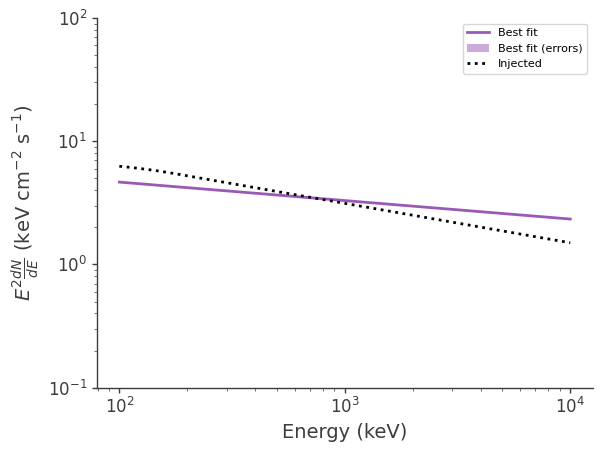

In [24]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.set_ylim(.1,100)

_ = ax.legend()

Plot the fitted spectrum convolved with the response, as well as the simulated source counts

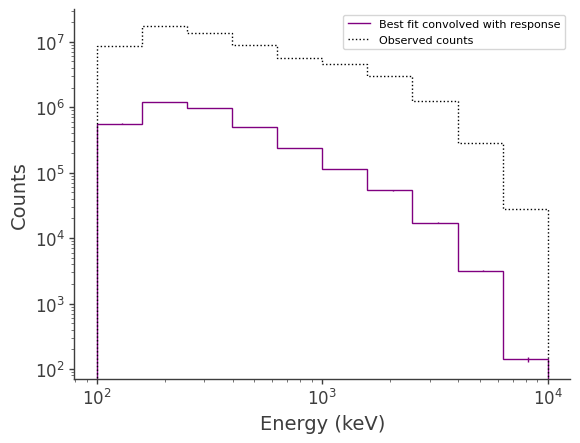

In [25]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').to_dense(copy=False).contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').to_dense(copy=False).contents, yerr=np.sqrt(expectation.project('Em').to_dense(copy=False).contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(mock_data.binned_data.project('Em').to_dense(copy=False).contents, binned_energy_edges, color = 'black', ls = ":", label = "Observed counts")
ax.errorbar(binned_energy, mock_data.binned_data.project('Em').to_dense(copy=False).contents, yerr=np.sqrt(mock_data.binned_data.project('Em').to_dense(copy=False).contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

_ = ax.legend()

Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts

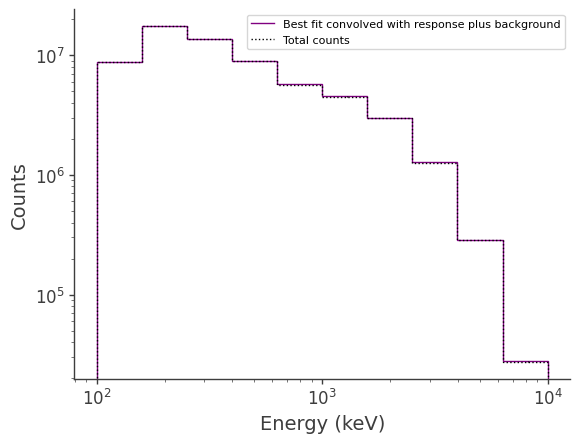

In [26]:
expectation_bkg = bkg.expectation(copy = True)

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').to_dense(copy=False).contents + expectation_bkg.project('Em').to_dense(copy=False).contents, binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').to_dense(copy=False).contents+expectation_bkg.project('Em').to_dense(copy=False).contents, yerr=np.sqrt(expectation.project('Em').to_dense(copy=False).contents+expectation_bkg.project('Em').to_dense(copy=False).contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(data.data.project('Em').to_dense(copy=False).contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, data.data.project('Em').to_dense(copy=False).contents, yerr=np.sqrt(data.data.project('Em').to_dense(copy=False).contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()